In [2]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import re

## Carregando dados



### Dados de hora em hora


In [3]:
# Loading data

data_full = pd.read_csv("merged_data.csv")
data_full.set_index('time',inplace=True)
data_full.index = pd.to_datetime(data_full.index)
data_full.head(3)

,ESP motor Current - phase A,ESP motor Current - phase B,ESP motor Current - phase C,VSD power frequency,ESP motor temperature,ESP differential pressure,ESP intake Pressure,Water Cut @ 20degC/1 atm,ESP intake temperature,ESP discharge pressure,...,extValues_ESP discharge temperature sensor,extValues_Choke Opening,extValues_Well head pressure,extValues_Well aligned to Train A,extValues_Well aligned to Train B,extValues_ESP Motor Voltage,extValues_ESP Vibration X,extValues_ESP Vibration Y,extValues_Well head Temperature,Failure distance
time,,,,,,,,,,,,,,,,,,,,,
2011-04-09 21:00:00,57.00,58.10,58.01,39.67,13.64,97.72,220.50,0.1,81.22,318.22,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1163 days 03:00:00
2011-04-09 22:00:00,66.05,68.63,68.00,39.75,13.64,83.10,204.45,0.1,81.22,287.55,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1163 days 02:00:00
2011-04-09 23:00:00,72.00,74.00,73.00,39.80,13.64,58.77,197.27,0.1,81.22,256.04,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1163 days 01:00:00


In [4]:
data_full.drop(data_full[data_full['VSD power frequency'] < 7].index,inplace=True)
data_full.drop(data_full[pd.isna(data_full['VSD power frequency'])].index,inplace=True)

data_full.index = data_full.index.tz_localize(None)

### Dados globais

In [5]:
data_failure = pd.read_excel("Peregrino ESP Run Life 240410 [SMALL].xlsx",skiprows=2)

# Função de substituição
def substituir(match):
    return f" {match.group(1)}"

# Substituição usando expressão regular
for dat in data_failure.index:
    data_failure.loc[dat,'Well Name'] = re.sub(r'\(#(\d+)\)', substituir, data_failure.loc[dat,'Well Name'])
    if len(data_failure.loc[dat,'Well Name']) in [4,5]:
        data_failure.loc[dat,'Well Name'] = f"{data_failure.loc[dat,'Well Name']} 1"

data_failure.set_index('Well Name',inplace=True);

c:\Users\Heitor\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
c:\Users\Heitor\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Conditional Formatting extension is not supported and will be removed
  for idx, row in parser.parse():


In [6]:
for well in data_full['Well Run'].unique():

    ind = data_failure.index==well
    fail_date = data_failure[ind]['Failure Date'].values

    end_date = data_full[data_full['Well Run'] == well].index.max()
    if (fail_date[0] - end_date).days < -1 and bool(data_failure[ind]['ESP Health'].values) is False:
        print(well,fail_date[0]-end_date,well,fail_date[0],end_date, data_failure[ind]['Reason for Pull'].values)

<Axes: xlabel='time'>

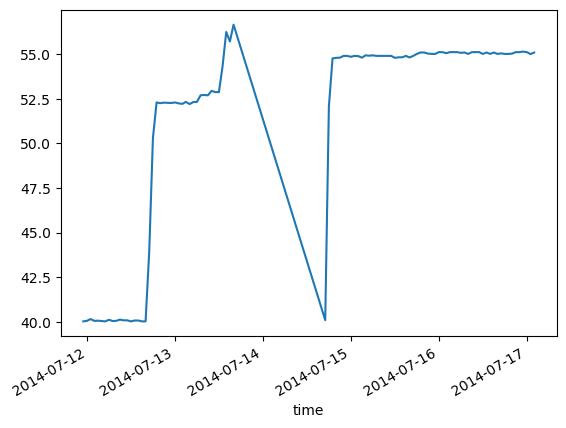

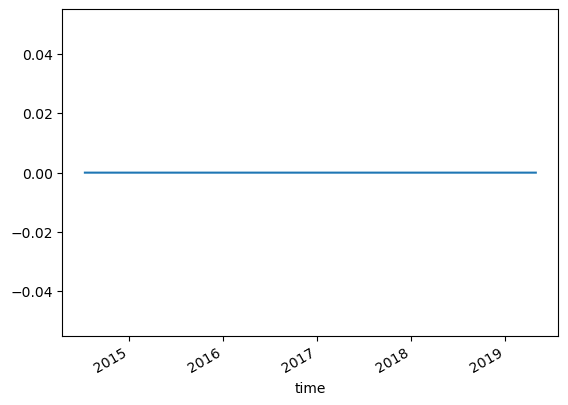

In [646]:
data_A = data_full[data_full['Well Run']== 'A-09 1']
data_B = data_full[data_full['Well Run']== 'A-09 2']

a = data_A['VSD power frequency'].iloc[8400:]
b = data_B['VSD power frequency']

data_A['VSD power frequency'].iloc[8400:8500].plot()


plt.figure()
(a-b).plot()

<Axes: xlabel='time'>

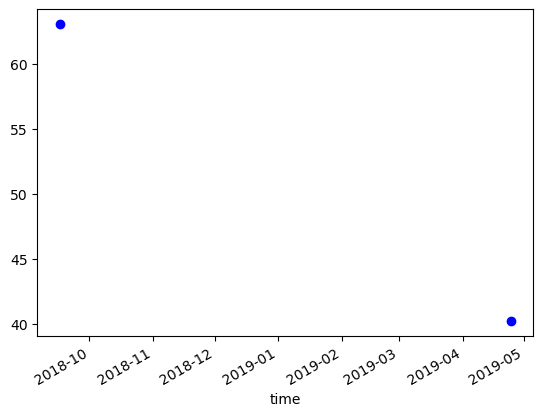

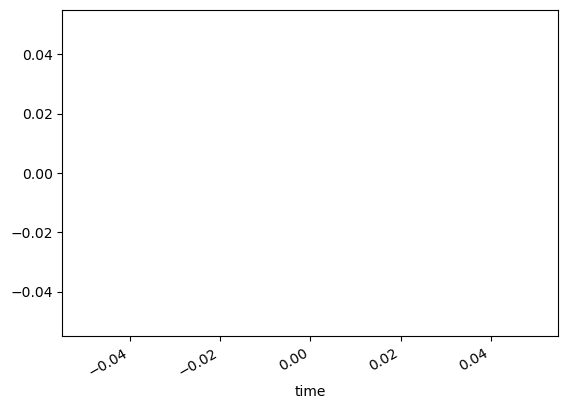

In [627]:
data_A = data_full[data_full['Well Run']== 'B-07 2']
data_B = data_full[data_full['Well Run']== 'B-07 3']

a = data_A['VSD power frequency'].iloc[12936:]
b = data_B['VSD power frequency']

data_A['VSD power frequency'].iloc[12936:12938].plot(style='bo')


plt.figure()
b.plot()

In [633]:
data_A = data_full[data_full['Well Run']== 'B-23 2']
data_B = data_full[data_full['Well Run']== 'B-23 3']

data_A['ESP motor temperature']

#data_B['ESP motor temperature']

time
2011-09-28 13:00:00     73.160
2011-09-28 14:00:00    103.190
2011-09-28 15:00:00    104.930
2011-09-28 16:00:00    104.910
2011-09-28 20:00:00    104.350
                        ...   
2018-12-29 11:00:00     81.176
2019-01-24 21:00:00    104.920
2019-04-05 20:00:00    106.180
2019-06-26 13:00:00    106.190
2020-04-07 06:00:00    106.040
Name: ESP motor temperature, Length: 18073, dtype: float64

In [638]:
np.sum(data_full['Well Run'] == 'B-23 1')

0

## Scatterplot A-10 1

In [248]:
well = 'A-10 1'

ind_well = data_full['Well Run']==well

data_well = data_full[ind_well]

data_well.head(3)

,ESP motor Current - phase A,ESP motor Current - phase B,ESP motor Current - phase C,VSD power frequency,ESP motor temperature,ESP differential pressure,ESP intake Pressure,Water Cut @ 20degC/1 atm,ESP intake temperature,ESP discharge pressure,...,extValues_ESP discharge pressure,extValues_ESP discharge temperature sensor,extValues_Choke Opening,extValues_Well head pressure,extValues_Well aligned to Train A,extValues_Well aligned to Train B,extValues_ESP Motor Voltage,extValues_ESP Vibration X,extValues_ESP Vibration Y,extValues_Well head Temperature
time,,,,,,,,,,,,,,,,,,,,,
2015-02-11 09:00:00,79.0,80.0,80.00,44.21,115.28,80.85,150.76,4.0,81.41,231.54,...,0.0,0.0,0.0,60.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-02-11 10:00:00,112.0,113.0,112.00,56.26,134.58,117.70,138.82,4.0,81.57,256.29,...,0.0,0.0,0.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-02-11 11:00:00,114.0,115.0,114.82,55.21,134.11,104.28,132.19,4.0,81.75,236.51,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


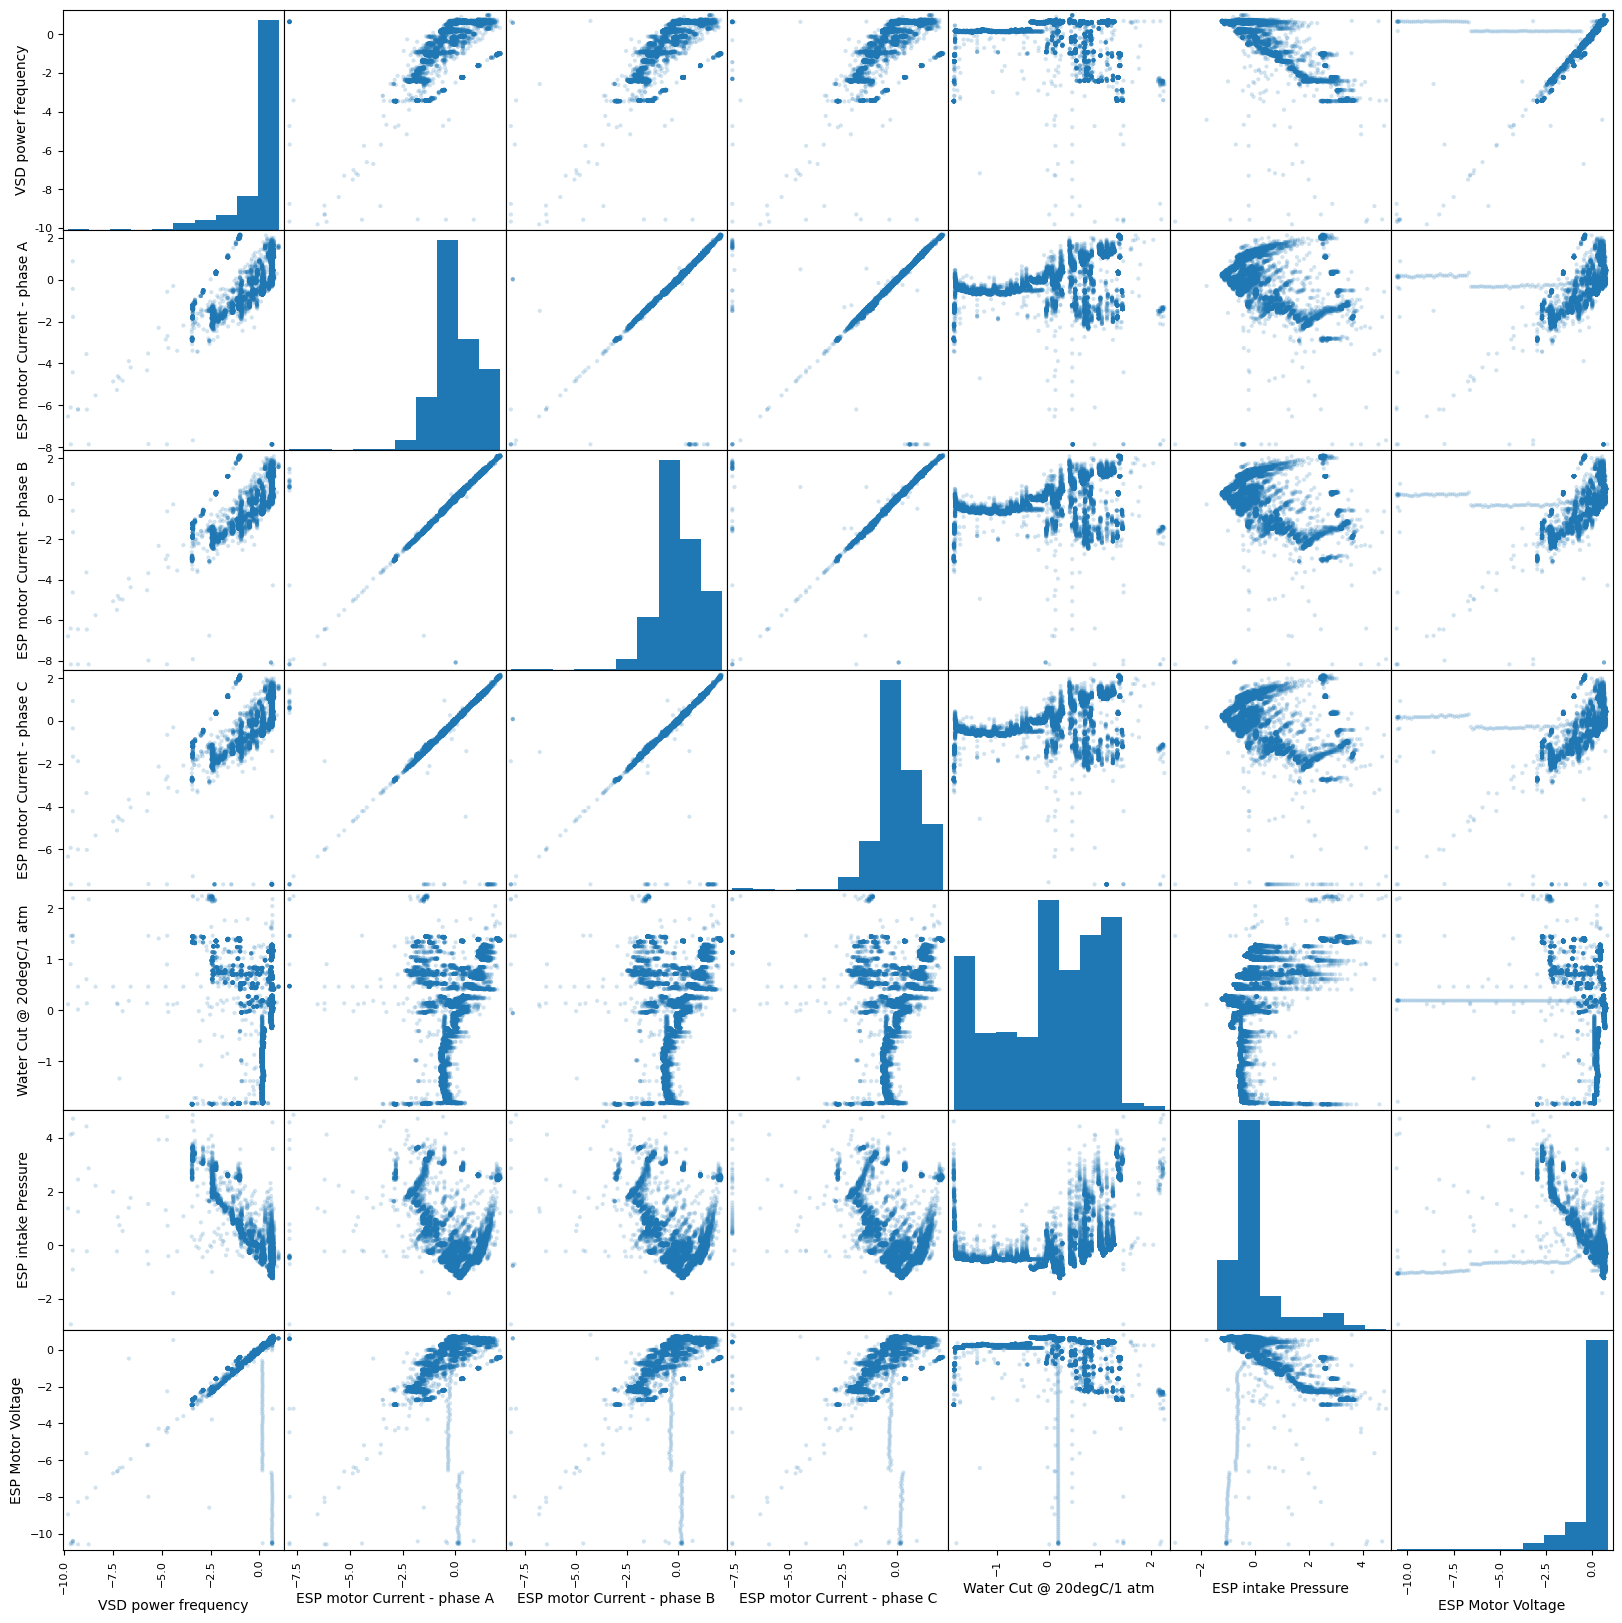

In [294]:
exog_vars = ['VSD power frequency','ESP motor Current - phase A','ESP motor Current - phase B','ESP motor Current - phase C','Water Cut @ 20degC/1 atm','ESP intake Pressure','ESP Motor Voltage'\
       ]

normalized_df=(data_well[exog_vars]-data_well[exog_vars].mean())/data_well[exog_vars].std()

pd.plotting.scatter_matrix(normalized_df, alpha=0.2, figsize=[20,20]);

## Scatterplot B-23 2

In [256]:
well = 'B-23 2'

ind_well = data_full['Well Run']==well

data_well = data_full[ind_well]

data_well.head(3)

,ESP motor Current - phase A,ESP motor Current - phase B,ESP motor Current - phase C,VSD power frequency,ESP motor temperature,ESP differential pressure,ESP intake Pressure,Water Cut @ 20degC/1 atm,ESP intake temperature,ESP discharge pressure,...,extValues_ESP discharge pressure,extValues_ESP discharge temperature sensor,extValues_Choke Opening,extValues_Well head pressure,extValues_Well aligned to Train A,extValues_Well aligned to Train B,extValues_ESP Motor Voltage,extValues_ESP Vibration X,extValues_ESP Vibration Y,extValues_Well head Temperature
time,,,,,,,,,,,,,,,,,,,,,
2011-09-28 13:00:00,50.54,52.54,51.54,40.11,73.16,46.67,204.30,0.84,69.13,252.96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-09-28 14:00:00,62.00,65.00,63.00,39.98,103.19,67.34,181.52,0.84,77.83,248.59,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-09-28 15:00:00,57.00,59.00,57.00,40.01,104.93,83.36,172.85,0.84,80.84,256.01,...,39.0,0.0,0.0,60.0,0.0,0.0,0.0,0.0,0.0,0.0


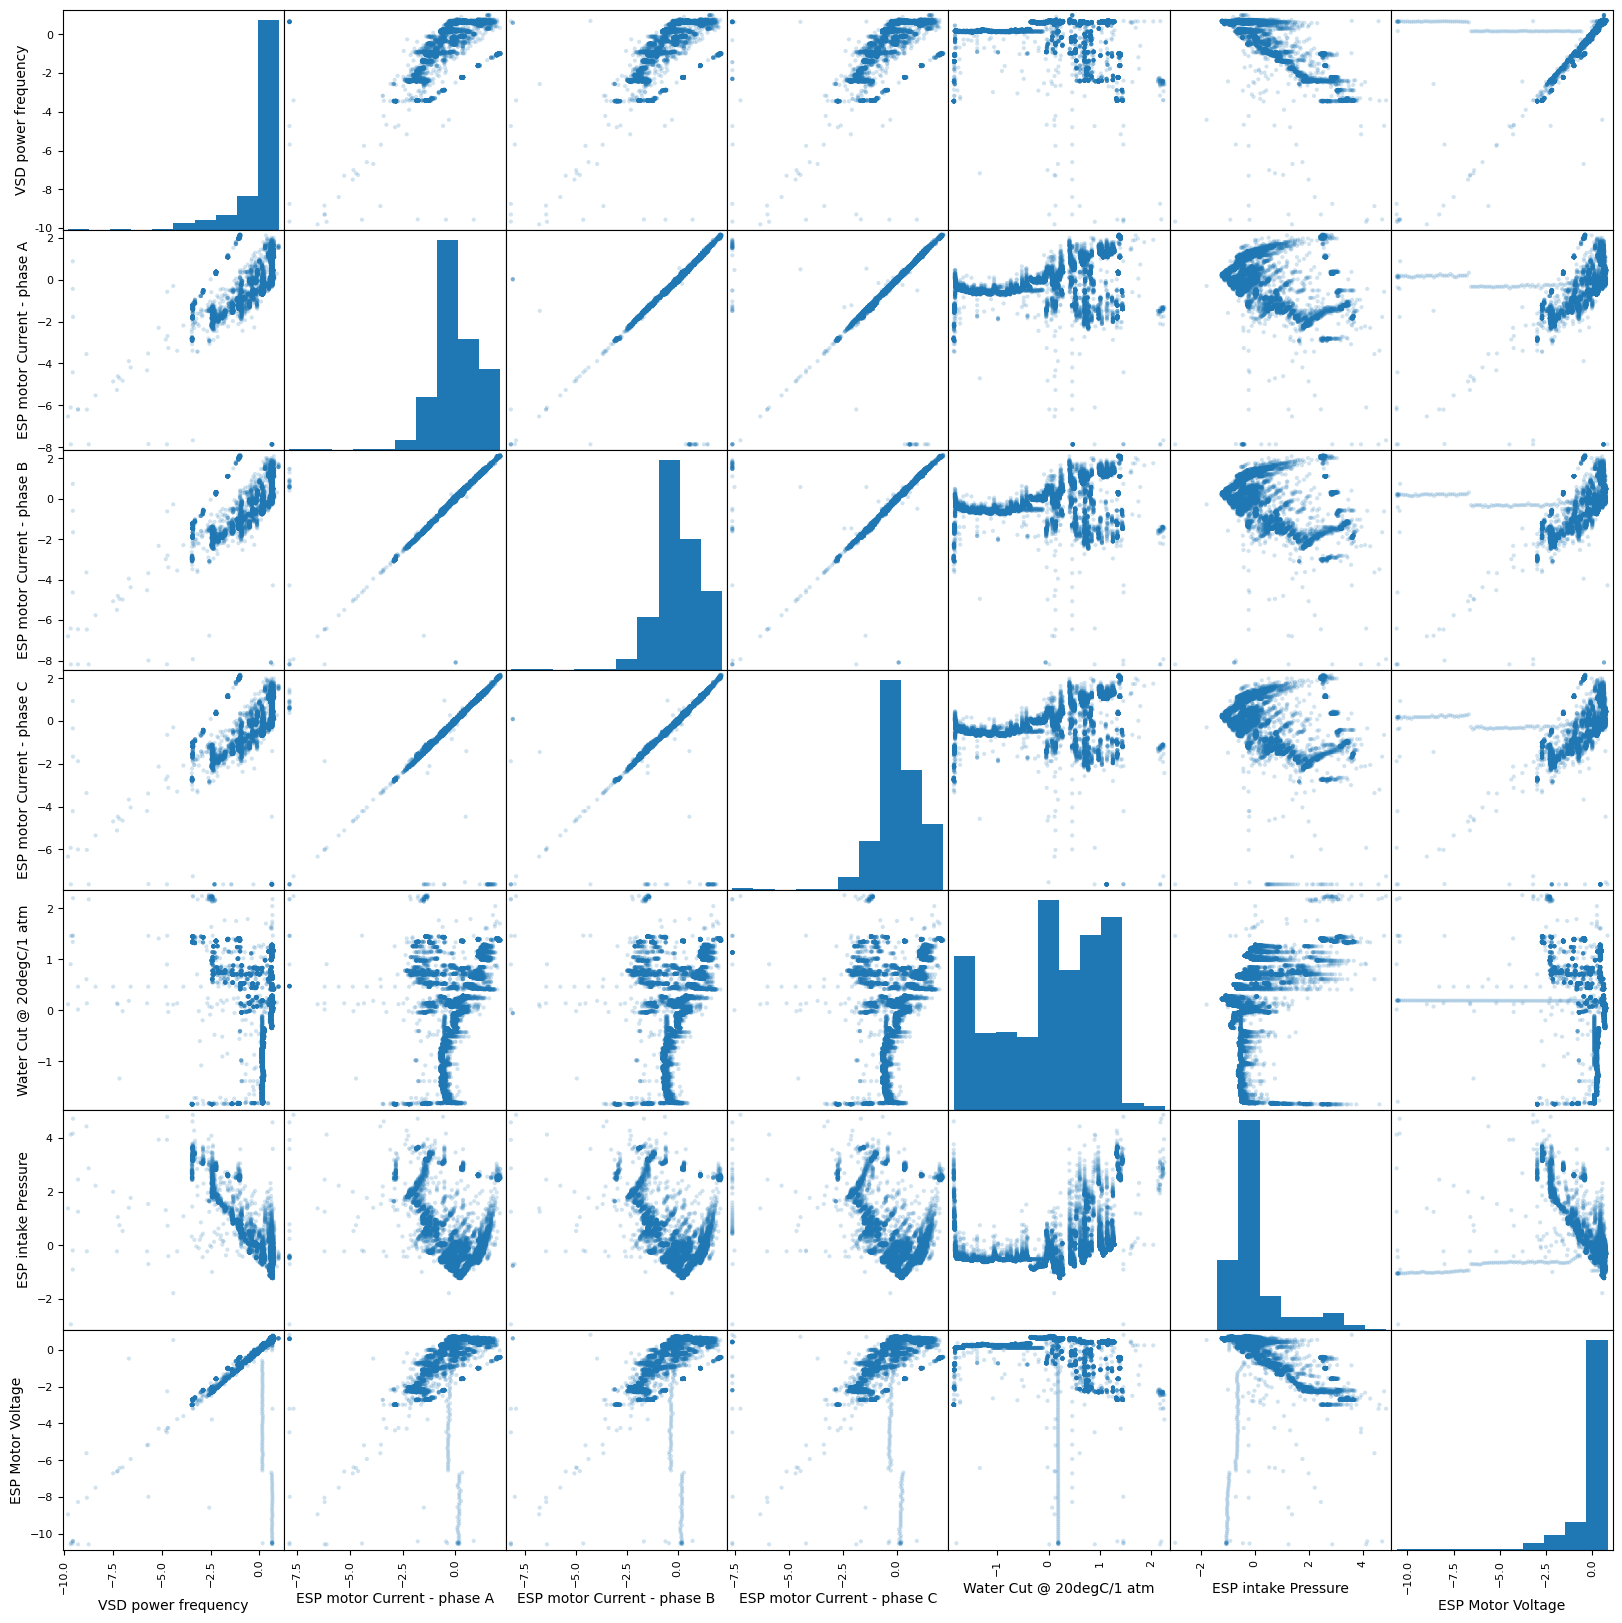

In [293]:
exog_vars = ['VSD power frequency','ESP motor Current - phase A','ESP motor Current - phase B','ESP motor Current - phase C','Water Cut @ 20degC/1 atm','ESP intake Pressure','ESP Motor Voltage'\
       ]

normalized_df=(data_well[exog_vars]-data_well[exog_vars].mean())/data_well[exog_vars].std()

pd.plotting.scatter_matrix(normalized_df, alpha=0.2, figsize=[20,20]);

## Separando dados em blocos

/tmp/ipykernel_10549/2734435297.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vsd_data.dropna(inplace=True)


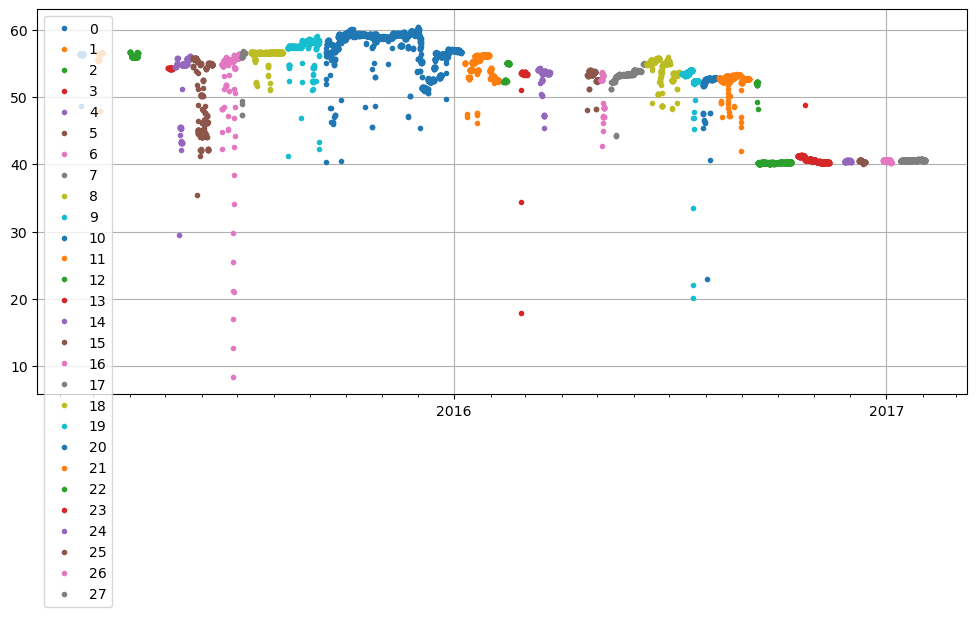

In [499]:
# Dividing data by month

# Getting info
vsd_name = 'VSD power frequency'
well = 'A-10 1'
vsd_data = data_full[data_full['Well Run'] ==well][vsd_name]

# Getting data time range
year1 = np.min(vsd_data.index.year)
month1 = np.min(vsd_data.index[vsd_data.index.year==year1].month)

year2 = np.max(vsd_data.index.year)
month2 = np.max(vsd_data.index[vsd_data.index.year==year2].month)+1
if month2 == 13:
    month2 = 1
    year2 += 1


# Creating date array
first = datetime.datetime(year1, month1, 1, 0, 0, 0)
last = datetime.datetime(year2, month2, 1, 0, 0, 0)
delta = datetime.timedelta(hours = 1)
dates = pd.date_range(start=first, end=last, freq='H')
days = pd.DataFrame(index = dates,
                   data = np.zeros(dates.size))
days.loc[vsd_data.index,0] = 1


# Dividing by groups

max_date_difference = 1

vsd_data.dropna(inplace=True)
border_ind = vsd_data.index[vsd_data.index.to_series().diff().dt.days>max_date_difference]

data_blocks = [None]*(border_ind.size+1)
num_blocks = 0

if border_ind.size == 0:
    block = vsd_data
    data_blocks[0] = block
    num_blocks = 1

else:
    for i in range(border_ind.size):
        
        if i>0:
            block =  vsd_data.loc[np.logical_and(vsd_data.index<border_ind[i],vsd_data.index>=border_ind[i-1])]
        else:
            block =  vsd_data.loc[vsd_data.index<border_ind[i]]
    
        if block.size > 0: 
            if (block.index[-1]-block.index[0]).days > max_date_difference:
                data_blocks[num_blocks] = block
                num_blocks += 1

    block =  vsd_data.loc[vsd_data.index>=border_ind[i]]
    if block.size > 0:
        if (block.index[-1]-block.index[0]).days > max_date_difference:
            data_blocks[num_blocks] = block
            num_blocks += 1


plt.figure()
for j in range(num_blocks):
    block = data_blocks[j]
    mn = block.mean()
    md = block.median()
    st = block.std()
    
    qt = (block-md).abs().quantile(q=0.90)


    #block.drop(block[np.abs(block-mn)>1*st].index,inplace=True)
    #c = b.drop(b[np.abs(b-md)>qt].index,inplace=False)
    
    plt.figure(1)
    plt.plot(block,'.',label=j)

    #plt.figure(2)
    #plt.plot(c,'.')


plt.legend()
for j in [1]:
    plt.figure(j)
    plt.grid(True)
    plt.gcf().set_size_inches(12,5)
    plt.gca().xaxis.set_minor_locator(mdates.MonthLocator())
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())

#from statsmodels.tsa.deterministic import TimeTrend
#trend_gen = TimeTrend(True, 1)
#trend_gen.in_sample(vsd.index)
#trend_gen.in_sample(vsd)

## Testando A-10 1 de novo

In [500]:
well = 'A-10 1'

b = 10
block = data_blocks[b]
ind = block.index

ind_well = data_full['Well Run']==well

data_well = data_full[ind_well].loc[ind]

data_well.head(3)

,ESP motor Current - phase A,ESP motor Current - phase B,ESP motor Current - phase C,VSD power frequency,ESP motor temperature,ESP differential pressure,ESP intake Pressure,Water Cut @ 20degC/1 atm,ESP intake temperature,ESP discharge pressure,...,extValues_ESP discharge pressure,extValues_ESP discharge temperature sensor,extValues_Choke Opening,extValues_Well head pressure,extValues_Well aligned to Train A,extValues_Well aligned to Train B,extValues_ESP Motor Voltage,extValues_ESP Vibration X,extValues_ESP Vibration Y,extValues_Well head Temperature
time,,,,,,,,,,,,,,,,,,,,,
2015-09-14 10:00:00,62.0,65.0,62.58,40.32,87.10,91.40,183.91,44.0,79.62,275.85,...,2.0,0.0,0.0,3.0,0.0,0.0,0.0,5.0,0.0,0.0
2015-09-14 11:00:00,111.0,112.0,109.00,51.92,114.23,100.63,142.51,44.0,82.11,243.23,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-09-14 12:00:00,107.0,108.0,105.00,52.65,118.52,116.39,135.07,44.0,82.67,251.49,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<Axes: xlabel='time'>

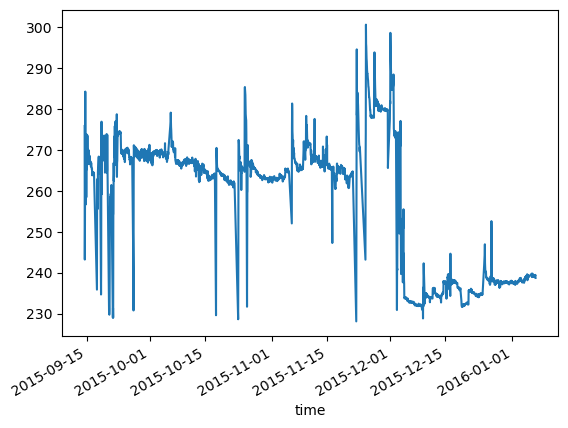

In [501]:
# Dado para testar

data_name = 'ESP discharge pressure'
y = data_well.loc[:,data_name]

y.dropna(inplace=True)
y.plot()

In [538]:
from statsmodels.tsa.stattools import adfuller

def check_adfuller(ts):
    # Dickey-Fuller test
    result = adfuller(ts, autolag='AIC')
    print('Test statistic: ' , result[0])
    print('p-value: '  ,result[1])
    print('Critical Values:' ,result[4])

def check_mean_std(ts,window):
    #Rolling statistics
    rolmean = ts.rolling(window).mean()
    rolstd = ts.rolling(window).std()
    plt.figure(figsize=(12,5))   
    mean = plt.plot(rolmean, color='black', label='Rolling Mean')
    
    plt.xlabel("Date")
    plt.ylabel("Mean Temperature")
    plt.title('Rolling Mean ')
    
    plt.figure(figsize=(12,5))   
    orig = plt.plot(ts, color='blue',label='Original')
    plt.plot(rolmean+2*rolstd, color='red', label='Bound')
    plt.plot(rolmean-2*rolstd, color='red')
    plt.xlabel("Date")
    plt.ylabel("Mean Temperature")
    plt.title('Rolling Mean ')
    plt.legend()

    plt.figure(figsize=(12,5))   
    std = plt.plot(rolstd, color='green', label = 'Rolling Std')
    plt.xlabel("Date")
    plt.ylabel("Mean Temperature")
    plt.title('Rolling Standard Deviation')
    plt.show()
    rolstd.head(3)



Test statistic:  -1.4418102210401837
p-value:  0.5620758809809945
Critical Values: {'1%': -3.4330273737125445, '5%': -2.8627228377894505, '10%': -2.567399672341618}


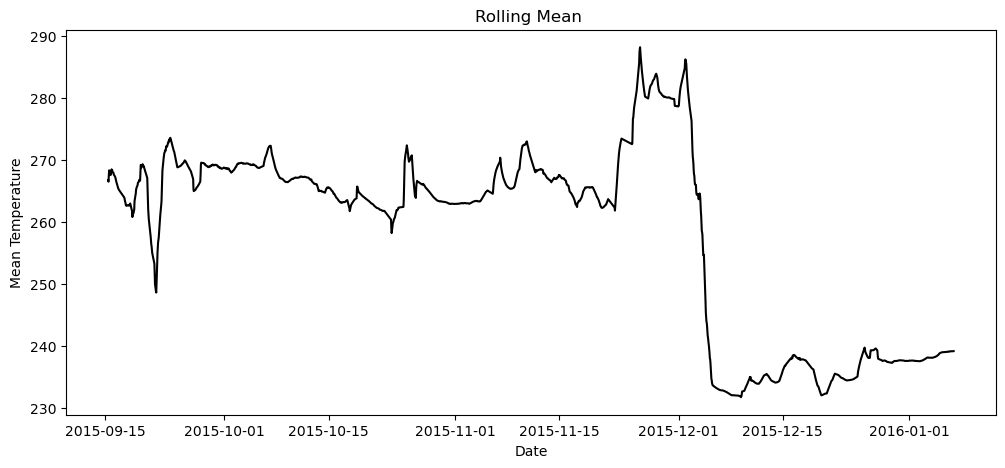

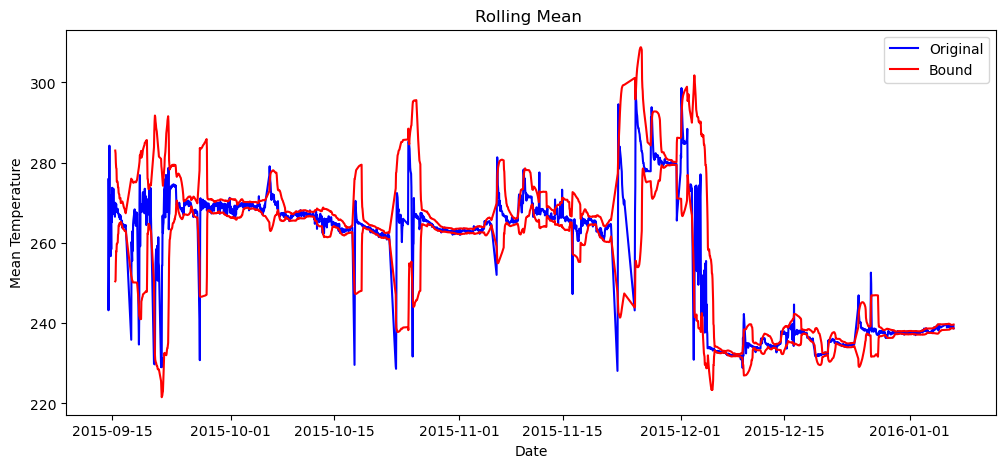

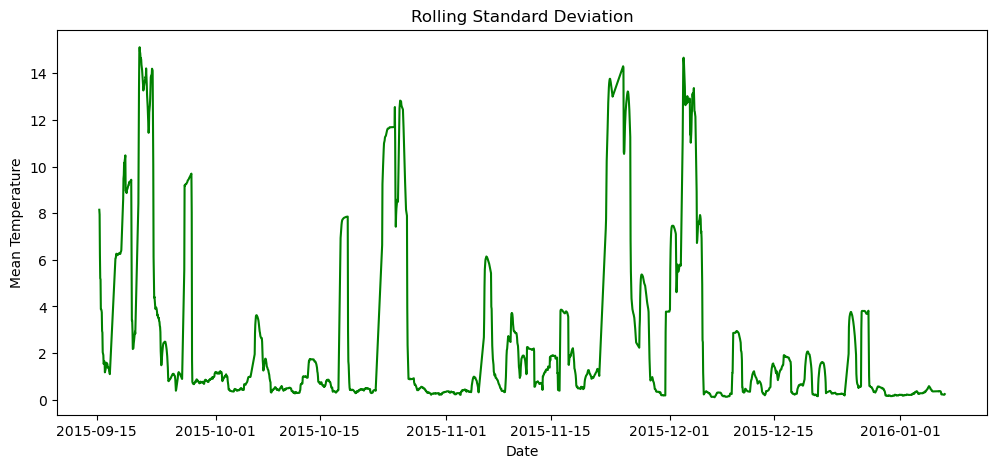

In [539]:
window = 24
check_adfuller(y);
check_mean_std(y,window);

Test statistic:  -15.75666885939847
p-value:  1.205330849645793e-28
Critical Values: {'1%': -3.4330394863905473, '5%': -2.8627281866400818, '10%': -2.567402520159153}


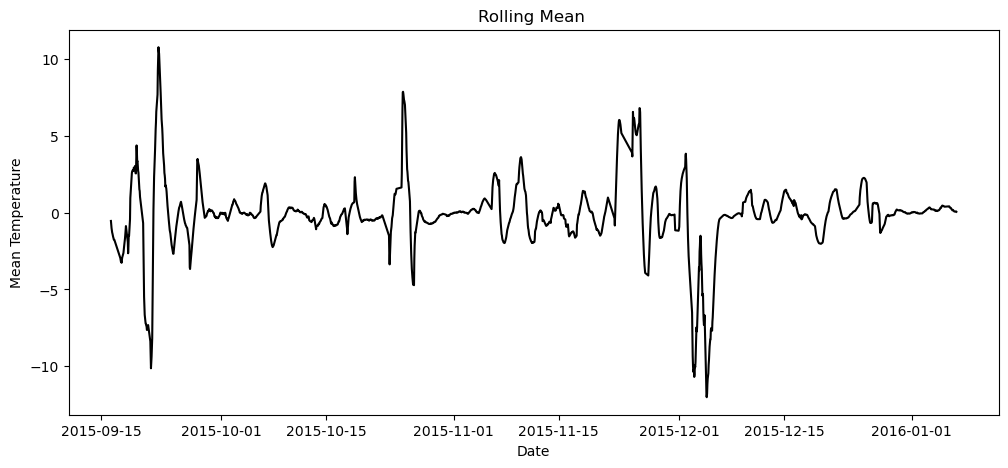

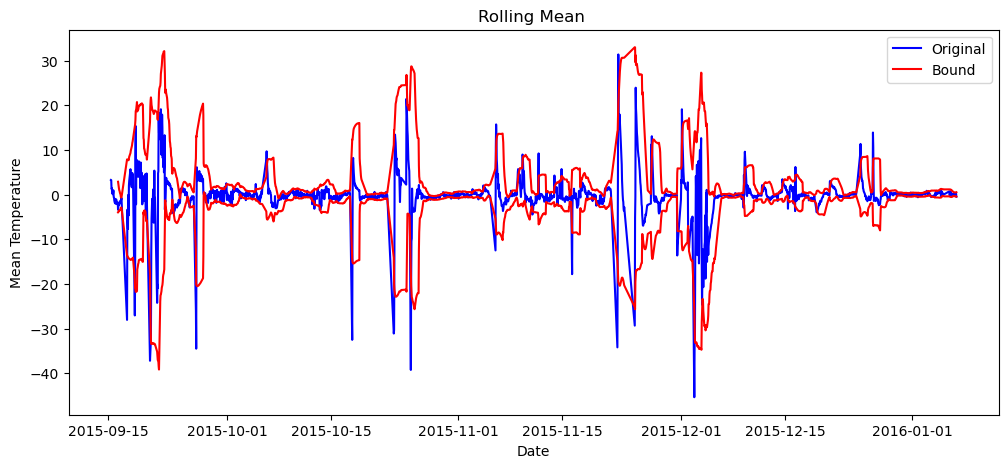

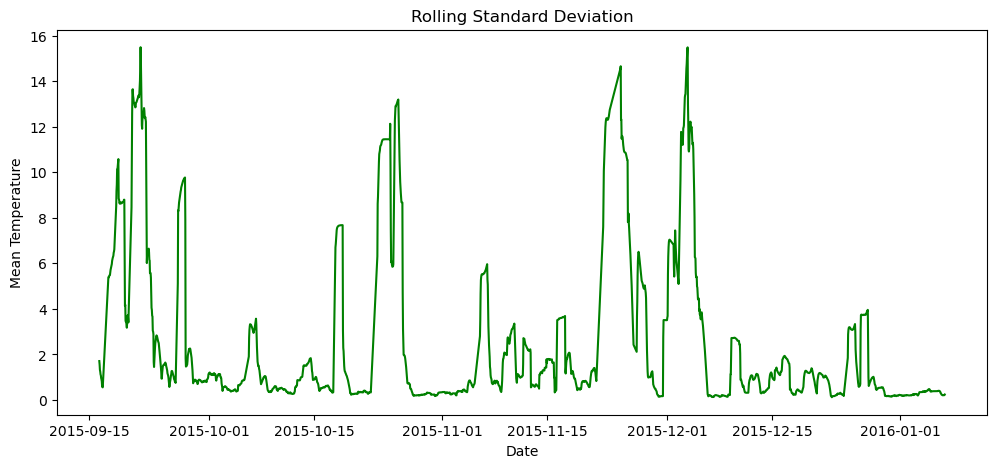

In [541]:
# Rolling mean

window = 24
ynew = y - y.rolling(window).mean()
ynew.dropna(inplace=True)

check_adfuller(ynew);
check_mean_std(ynew,window);

Test statistic:  -19.61180742440974
p-value:  0.0
Critical Values: {'1%': -3.4330273737125445, '5%': -2.8627228377894505, '10%': -2.567399672341618}


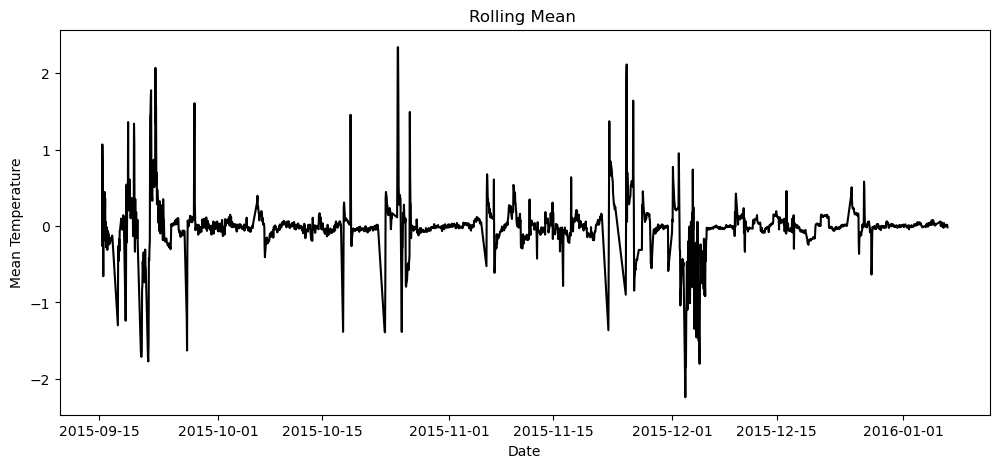

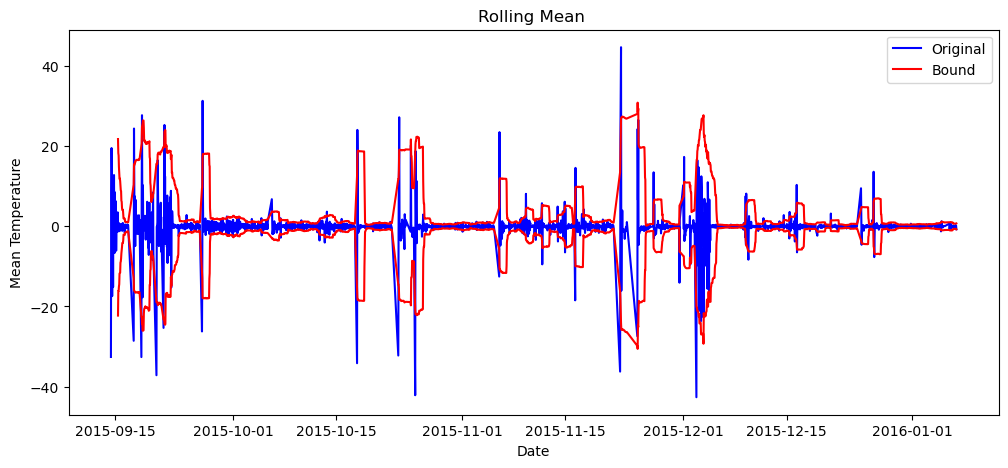

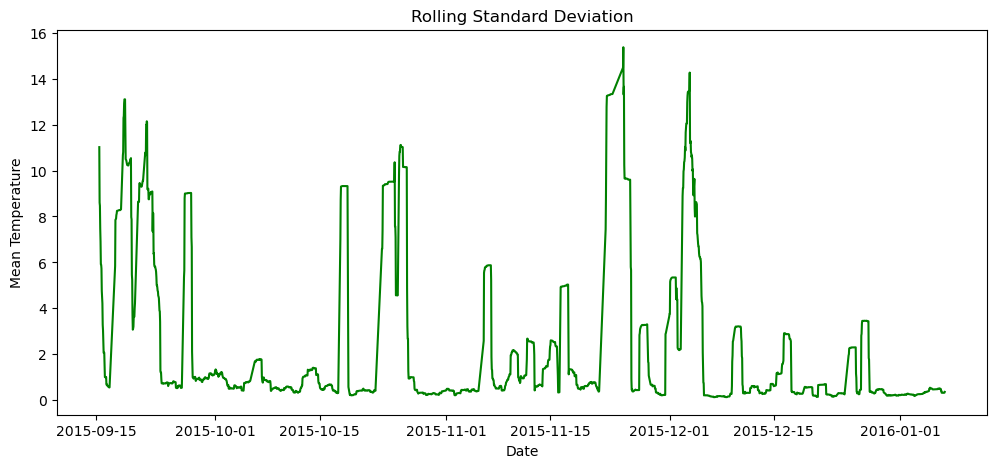

In [542]:
# Difference

ynew = y - y.shift()
ynew.dropna(inplace=True)


check_adfuller(ynew);
check_mean_std(ynew,window);

### Outliers

Ft = 0.958021582308671 
Fs = 0.3446258672262633


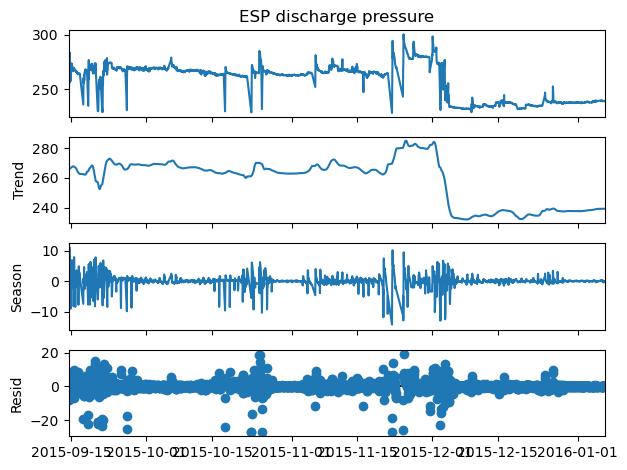

In [509]:
from statsmodels.tsa.seasonal import STL
import matplotlib.dates as mdates

res = STL(y, period=24).fit();
res.plot();

FT = max(0,1-res.resid.var()/(res.trend+res.resid).var())
FS = max(0,1-res.resid.var()/(res.seasonal+res.resid).var())

print(f'Ft = {FT} \nFs = {FS}')


(2461, 2060, 83.70581064607883)

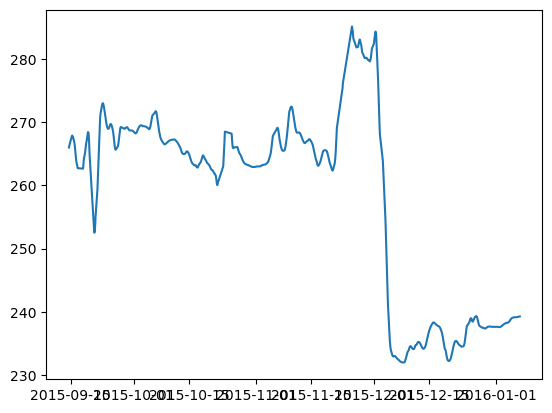

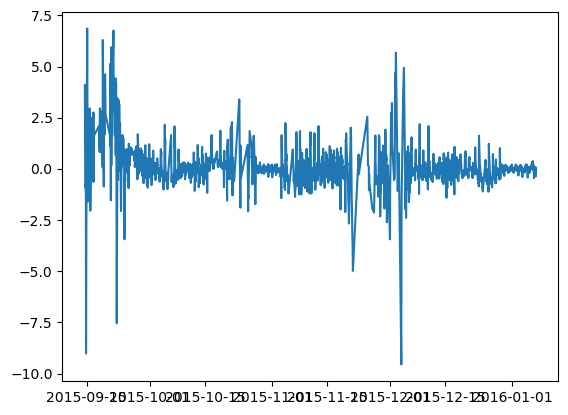

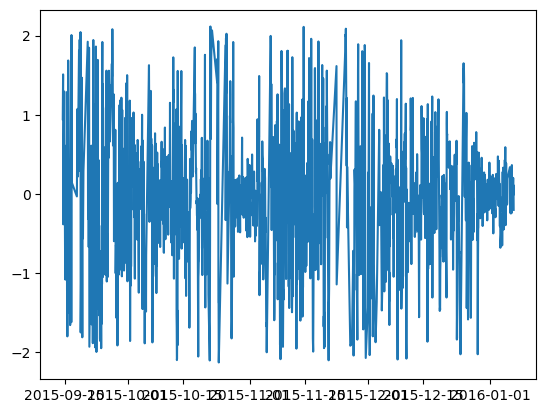

In [510]:
# Select the first quantile
Q1 = res.resid.quantile(.25)

# Select the third quantile
Q3 = res.resid.quantile(.75)

# Create a mask inbeetween q1 & q3
IQR = Q3 - Q1

no_outliers = (Q1 - 1.5*IQR < res.resid) &  (res.resid < Q3 + 1.5*IQR)

plt.plot(res.trend[no_outliers])
plt.figure()
plt.plot(res.seasonal[no_outliers])
plt.figure()
plt.plot(res.resid[no_outliers])

no_outliers.size,no_outliers.sum(),no_outliers.sum()/no_outliers.size*100



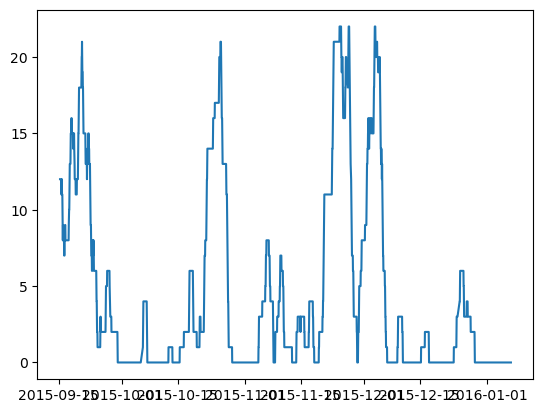

In [511]:

outliers= no_outliers == False
plt.plot(outliers.rolling(24).sum())

In [527]:
data_well.loc[:,data_well.isna().sum() > 100]


,ESP discharge temperature sensor,max_change_ESP discharge temperature sensor
time,,
2015-09-14 10:00:00,NaN,NaN
2015-09-14 11:00:00,NaN,NaN
2015-09-14 12:00:00,NaN,NaN
2015-09-14 13:00:00,NaN,NaN
2015-09-14 14:00:00,NaN,NaN
...,...,...
2016-01-06 19:00:00,NaN,NaN
2016-01-06 20:00:00,NaN,NaN
2016-01-06 21:00:00,NaN,NaN
